<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Comparison_Long_Only_vs_Trend_follow_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d willianoliveiragibin/comparison-long-only-vs-trend-follow

# Unziping the downloaded file
!unzip comparison-long-only-vs-trend-follow.zip

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/willianoliveiragibin/comparison-long-only-vs-trend-follow
License(s): CC0-1.0
comparison-long-only-vs-trend-follow.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  comparison-long-only-vs-trend-follow.zip
  inflating: Comparison Long Only vs Trend follow new.csv  


In [4]:
df = pd.read_csv('Comparison Long Only vs Trend follow new.csv')
df.head(11)

,Date,CL1,CL2,Roll Coef,day of month,Roll last month,is end of month,Date,month close,roll coef,...,trading cost,Unnamed: 25,pos aver7 aver9,perf aver7 aver9,aver7 aver9 reinvested,aver7 aver9 not reinvested,0,0.1,trading cost .1,0.2
0,1/2/1985,"25,92","25,81","-0,00424382716",1,0,0,1/31/2000,"27,64","-0,03639514731",...,0,0,0,0,0,0,0,0,0,0
1,1/3/1985,"25,84","25,79","-0,00193498452",2,0,0,2/29/2000,"30,43","-0,03272727273",...,0,0,0,0,0,0,0,0,0,0
2,1/4/1985,"25,18","25,19","0,0003971405878",3,0,0,3/31/2000,"26,9","-0,06216472073",...,0,0,0,0,0,0,0,0,0,0
3,1/7/1985,"25,56","25,6","0,001564945227",4,0,0,4/28/2000,"25,74","-0,04849432929",...,0,0,0,0,0,0,0,0,0,0
4,1/8/1985,"25,48","25,51","0,001177394035",5,0,0,5/31/2000,"29,01","-0,007765023633",...,0,0,0,0,0,0,0,0,0,0
5,1/9/1985,"25,43","25,43",0,6,0,0,6/30/2000,"32,5","-0,05114155251",...,0,0,0,0,0,0,0,0,0,0
6,1/10/1985,"25,76","25,8","0,001552795031",7,0,0,7/31/2000,"27,43","-0,04070131497",...,0,0,0,0,0,0,0,0,0,0
7,1/11/1985,"25,77","25,8","0,001164144354",8,0,0,8/31/2000,"33,12","-0,02692548528",...,0,0,0,0,0,0,0,0,0,0
8,1/14/1985,"26,12","26,34","0,008422664625",9,0,0,9/29/2000,"30,84","-0,03340757238",...,0,0,0,0,0,0,0,0,0,0
9,1/15/1985,"25,91","25,89","-0,0007719027403",10,"-0,0007719027403",0,10/31/2000,"32,7","-0,02457845099",...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.tail(11)

,Date,CL1,CL2,Roll Coef,day of month,Roll last month,is end of month,Date,month close,roll coef,...,trading cost,Unnamed: 25,pos aver7 aver9,perf aver7 aver9,aver7 aver9 reinvested,aver7 aver9 not reinvested,0,0.1,trading cost .1,0.2
255,1/9/1986,"25,9","24,65","-0,04826254826",6,"-0,04603580563",0,4/30/2021,"63,58","0,0007878978884",...,"0,1009601466","1,562285828",1,"0,07425539631",0,"1,992668108",0,"0,0004718464926","0,03542124904","1,957246859"
256,1/10/1986,"25,79","24,64","-0,04459092672",7,"-0,04603580563",0,5/28/2021,"66,32","-0,000152975371",...,"0,1009601466","1,604593243",1,"0,0423074151",0,"2,034975523",0,"0,0004523522316","0,03542124904","1,999554274"
257,1/13/1986,"25,08","23,72","-0,05422647528",8,"-0,04603580563",0,6/30/2021,"73,47","-0,003527088036",...,"0,1009601466","1,712556834",1,"0,1079635906",0,"2,142939114",0,"0,0004083299306","0,03542124904","2,107517865"
258,1/14/1986,"24,96","23,63","-0,05328525641",9,"-0,04603580563",0,7/30/2021,"73,95","-0,003768318214",...,"0,1009601466","1,7226172",1,"0,01006036693",0,"2,152999481",0,"0,0004056795132","0,03542124904","2,117578232"
259,1/15/1986,"25,15","23,86","-0,05129224652",10,"-0,05129224652",0,8/31/2021,"68,5","-0,003360607832",...,"0,1009601466","1,652687074",1,"-0,06993012668",0,"2,083069354",0,"0,0004379562044","0,03542124904","2,047648105"
260,1/16/1986,"24,11","22,86","-0,05184570718",11,"-0,05129224652",0,9/30/2021,"75,03","-0,003856218152",...,"0,1009601466","1,751376149",1,"0,09868907498",0,"2,181758429",0,"0,000399840064","0,03542124904","2,14633718"
261,1/17/1986,"23,55","22,6","-0,04033970276",12,"-0,05129224652",0,10/29/2021,"83,57","-0,006641249539",...,"0,1009601466","1,869053505",1,"0,1176773564",0,"2,299435785",0,"0,0003589804954","0,03542124904","2,264014536"
262,1/20/1986,"21,27","21,6","0,01551480959",13,"-0,05129224652",0,11/30/2021,"66,18","-0,01361554648",...,"0,1009601466","1,667605728",1,"-0,2014477776",0,"2,097988008",0,"0,0004533091568","0,03542124904","2,062566759"
263,1/21/1986,"20,59","20,81","0,01068479845",14,"-0,05129224652",0,12/31/2021,"75,21","-0,002969037184",...,"0,1038741825","1,514630089",1,"0,1500616027",0,"2,24804961",0,"0,0003988831272","0,03542124904","2,212628361"
264,1/22/1986,"20,39","20,28","-0,005394801373",15,"-0,05129224652",0,1/31/2022,"88,15","-0,006203769983",...,"0,1068168014","1,686708096",1,"0,1750206261",0,"2,423070236",0,"0,0003403289847","0,03542124904","2,387648987"


In [6]:
df.shape

(266, 34)

In [7]:
df.columns

Index(['Date', 'CL1', 'CL2', 'Roll Coef', 'day of month', 'Roll last month ',
       'is end of month ', 'Date ', 'month close ', 'roll coef ',
       'perf month init', 'perf month corr', 'Long Only reinvested ',
       'Long Only not reinvested ', 'Pos strat 7', 'perf strat7',
       'strat 7 reinvested ', 'strat 7 not reinvested ', 'Pos strat 9',
       'perf strat9', 'strat 9 reinvested ', 'strat 9 not reinvested ',
       'Unnamed: 22', 'Unnamed: 23', 'trading cost ', 'Unnamed: 25',
       'pos aver7 aver9', 'perf aver7 aver9', 'aver7 aver9 reinvested ',
       'aver7 aver9 not reinvested ', '0', '0.1', 'trading cost .1', '0.2'],
      dtype='object')

In [8]:
df.dtypes

,0
Date,object
CL1,object
CL2,object
Roll Coef,object
day of month,int64
Roll last month,object
is end of month,int64
Date,object
month close,object
roll coef,object


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date                         266 non-null    object 
 1   CL1                          266 non-null    object 
 2   CL2                          266 non-null    object 
 3   Roll Coef                    266 non-null    object 
 4   day of month                 266 non-null    int64  
 5   Roll last month              266 non-null    object 
 6   is end of month              266 non-null    int64  
 7   Date                         266 non-null    object 
 8   month close                  266 non-null    object 
 9   roll coef                    266 non-null    object 
 10  perf month init              265 non-null    object 
 11  perf month corr              265 non-null    object 
 12  Long Only reinvested         265 non-null    object 
 13  Long Only not reinve

In [11]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,266,266,1/23/1986,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CL1,266,205,"27,31",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CL2,266,211,"26,71",4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Roll Coef,266,264,"-0,01282051282",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day of month,266.0,NaN,NaN,NaN,10.804511,6.030061,1.0,6.0,11.0,16.0,23.0
Roll last month,266,14,"-0,02099105299",23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is end of month,266.0,NaN,NaN,NaN,0.045113,0.207943,0.0,0.0,0.0,0.0,1.0
Date,266,266,2/28/2022,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month close,266,261,"92,19",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
roll coef,266,265,"0,003692762186",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df.isnull().sum()

,0
Date,0
CL1,0
CL2,0
Roll Coef,0
day of month,0
Roll last month,0
is end of month,0
Date,0
month close,0
roll coef,0


In [13]:
df.duplicated().sum()

np.int64(0)

# Handling Outliers


In [14]:
Q1 = df['Pos strat 7'].quantile(0.25)
Q3 = df['Pos strat 7'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_Outliers = df[(df['Pos strat 7'] >= lower_bound) | (df['Pos strat 7'] <= upper_bound)].copy()

print(f'Original Shape: {len(df)}')
print(f'Shape after outlier handling: {len(df_Outliers)}')

Original Shape: 266
Shape after outlier handling: 264


# Univariate Analysis

In [ ]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

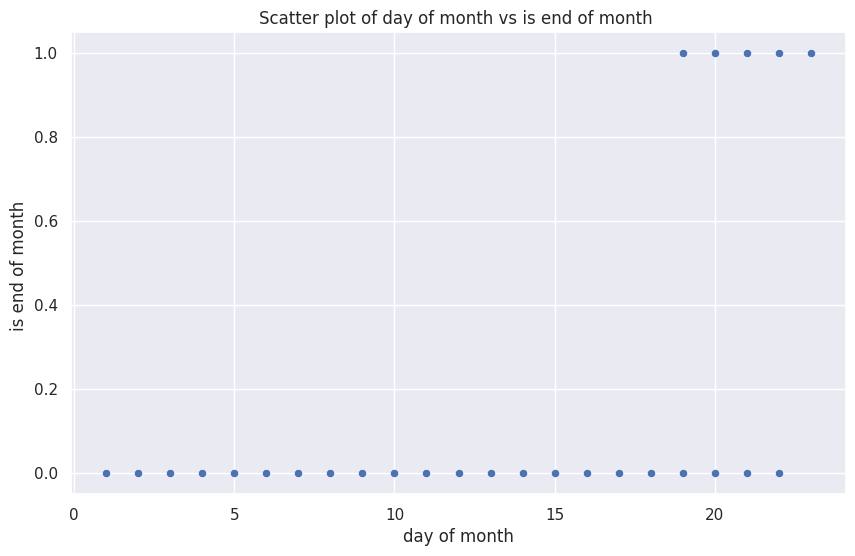

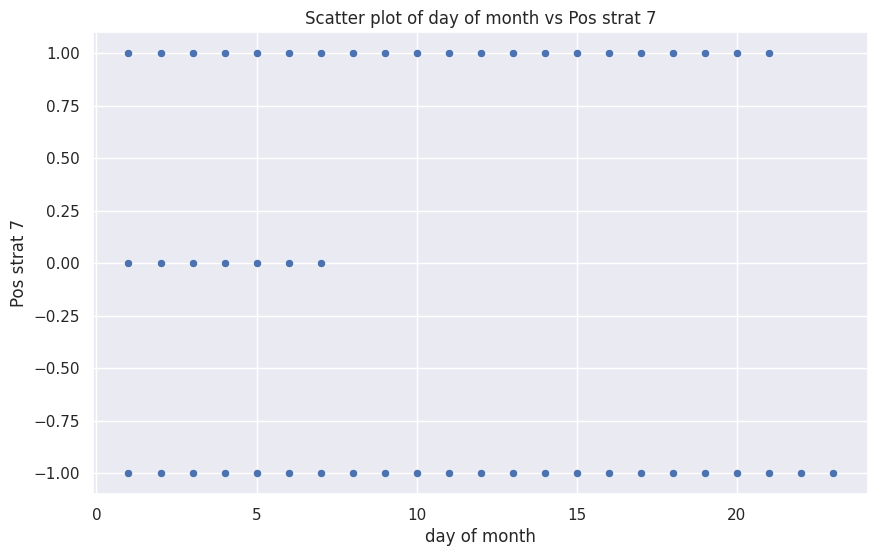

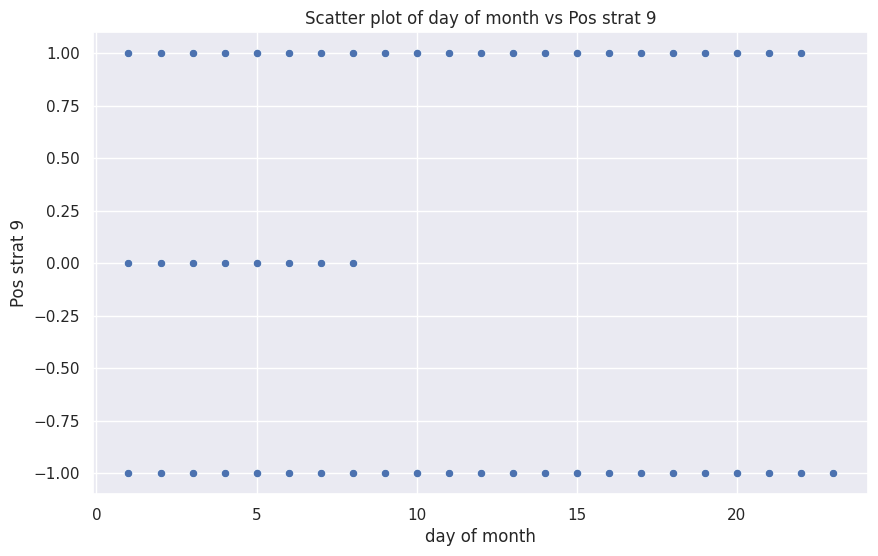

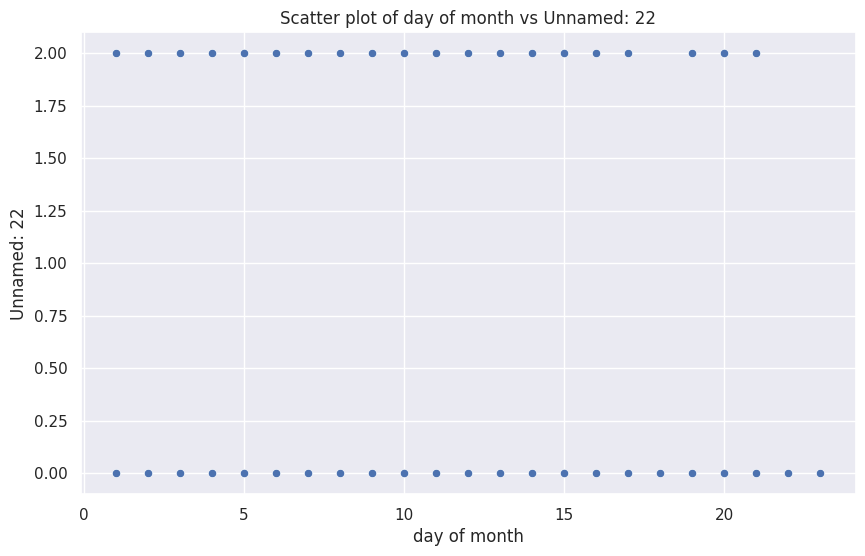

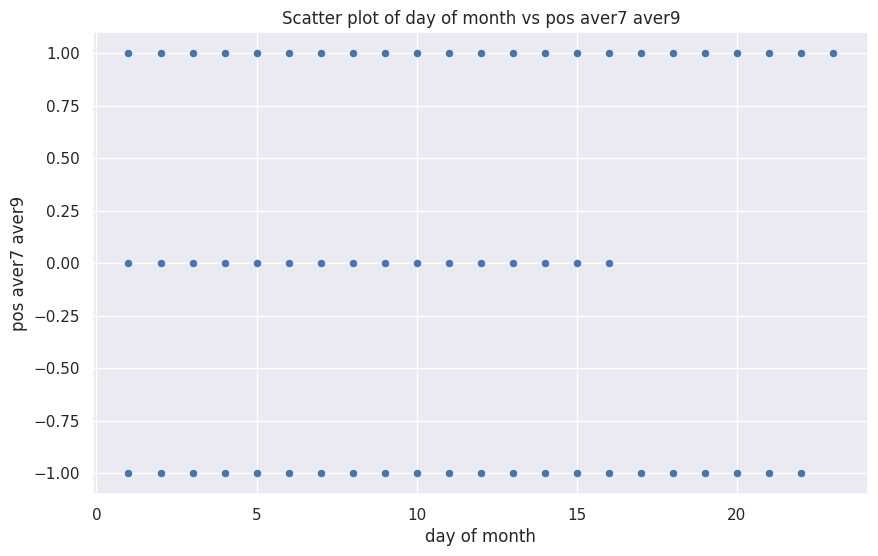

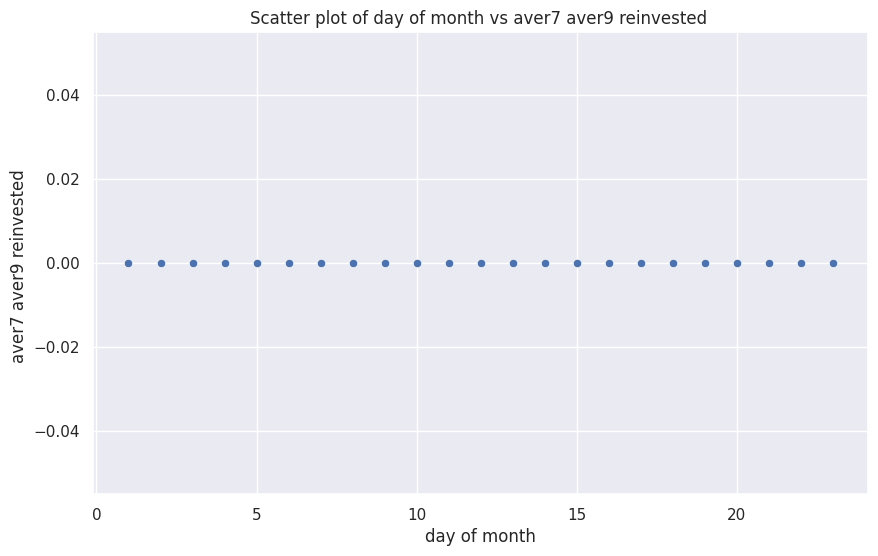

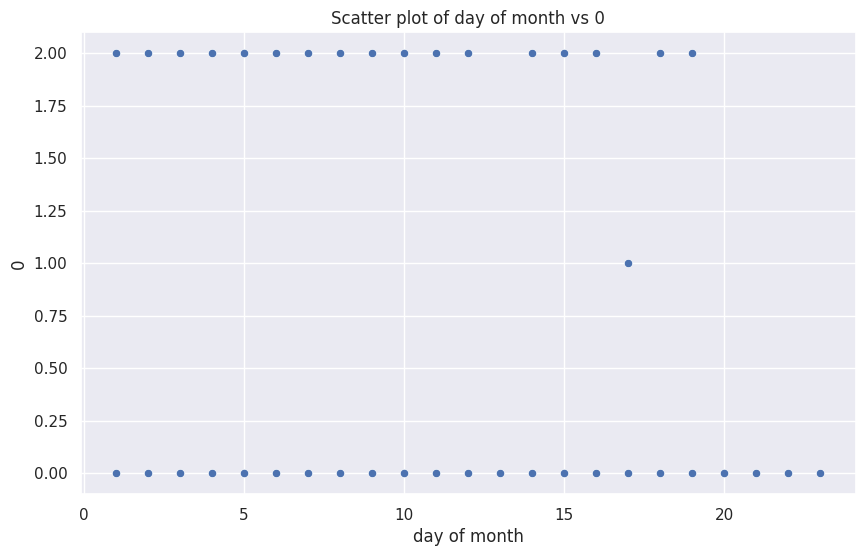

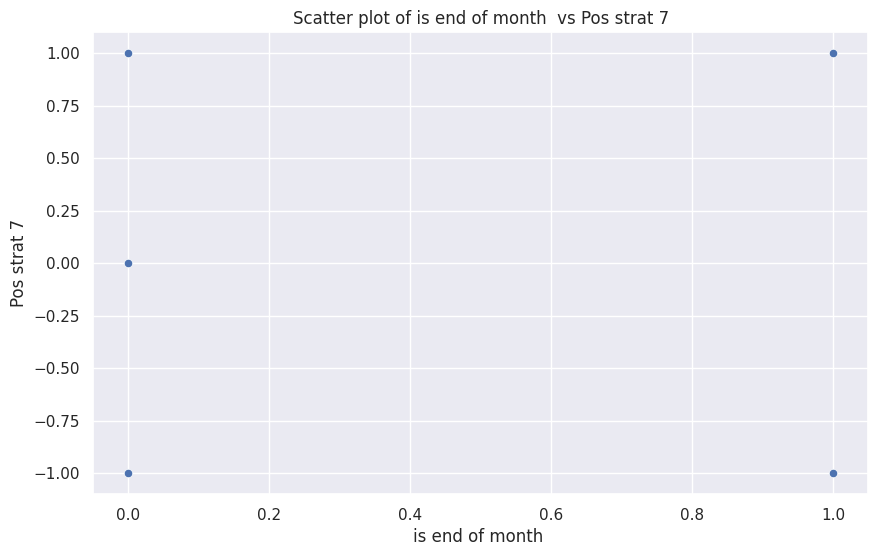

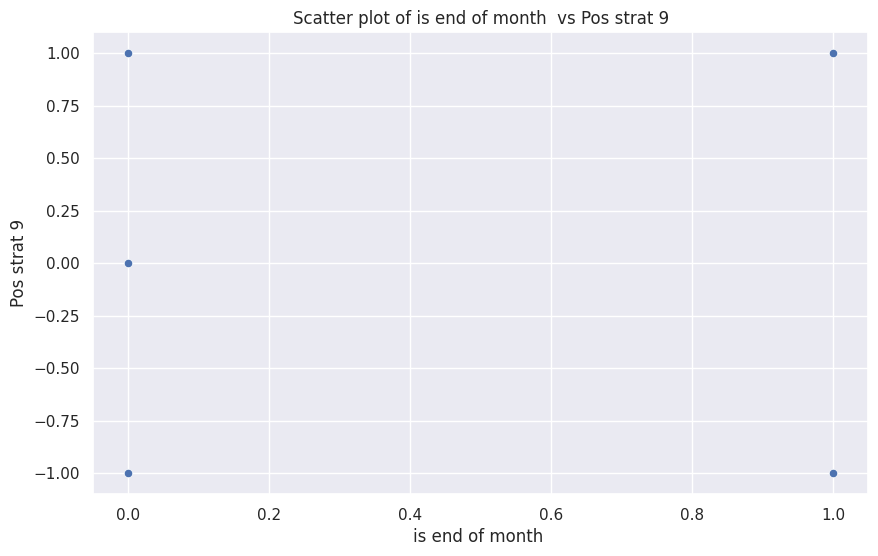

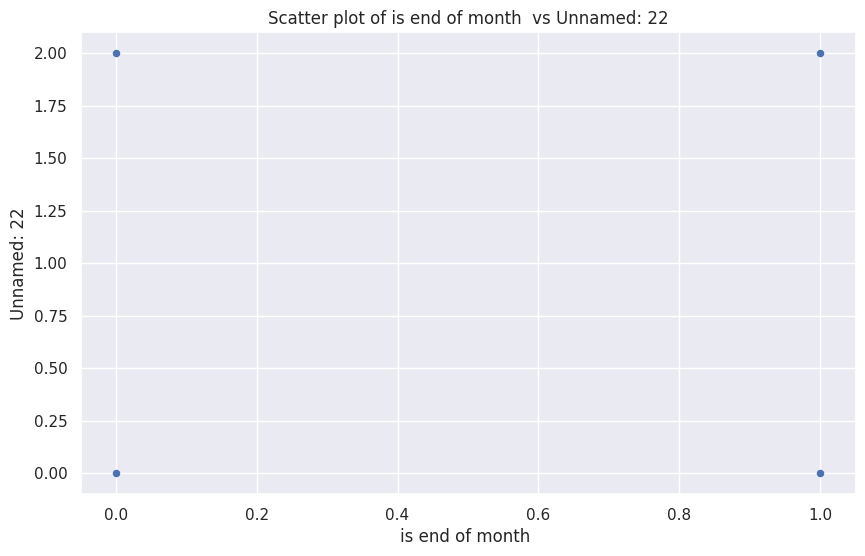

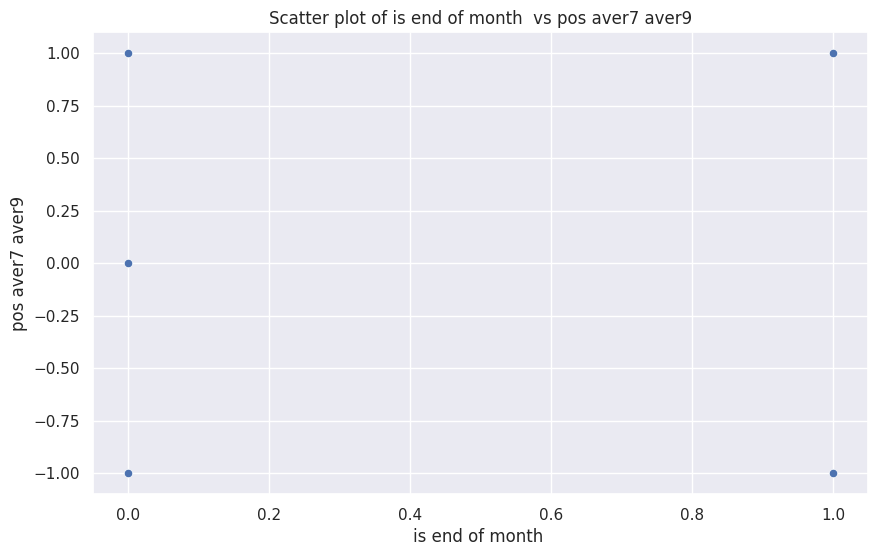

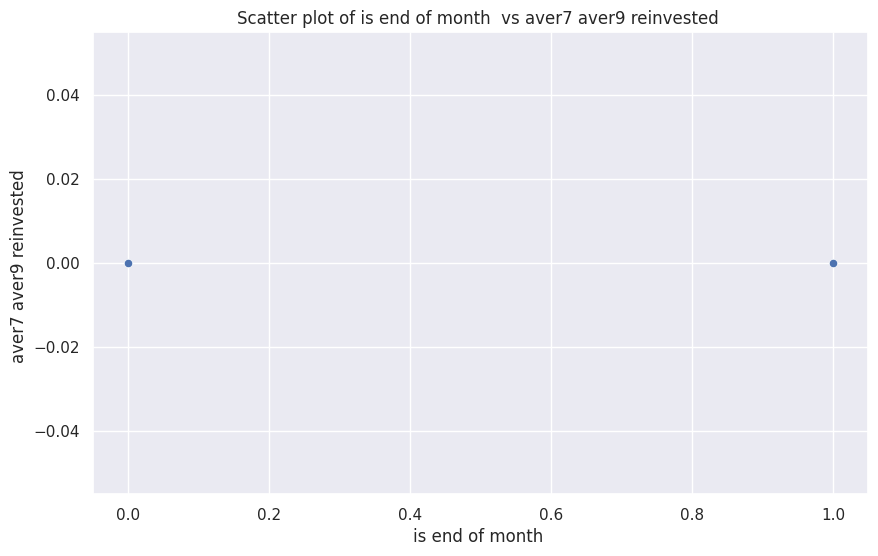

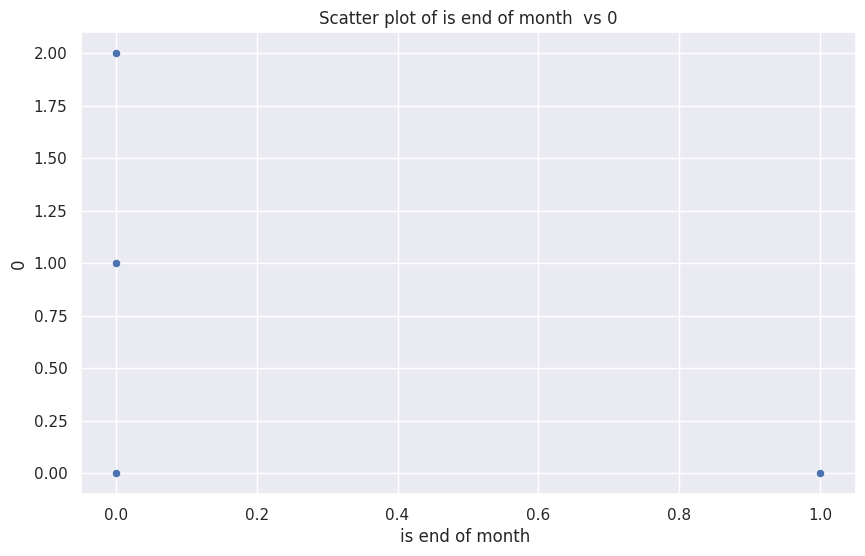

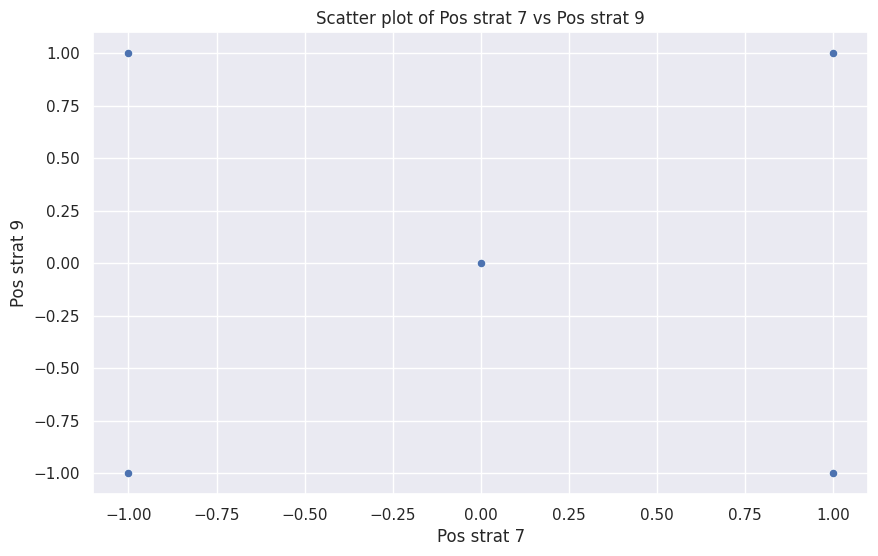

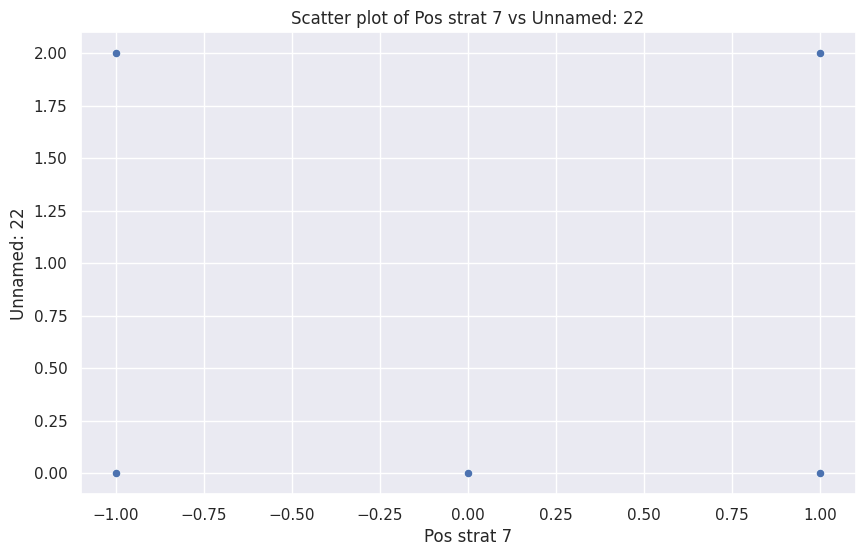

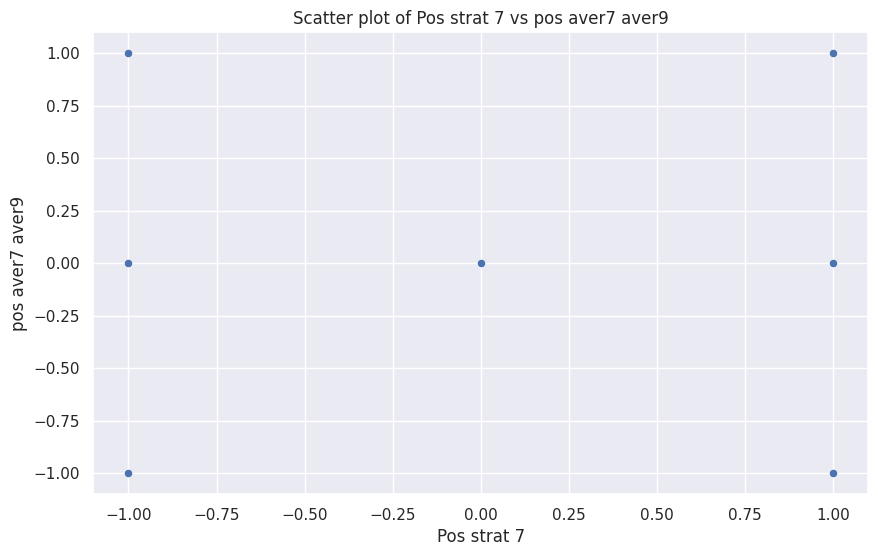

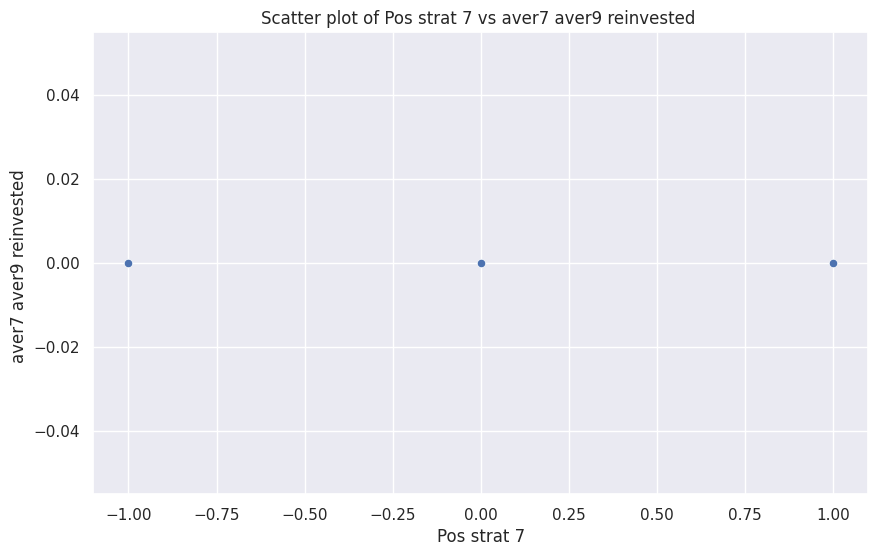

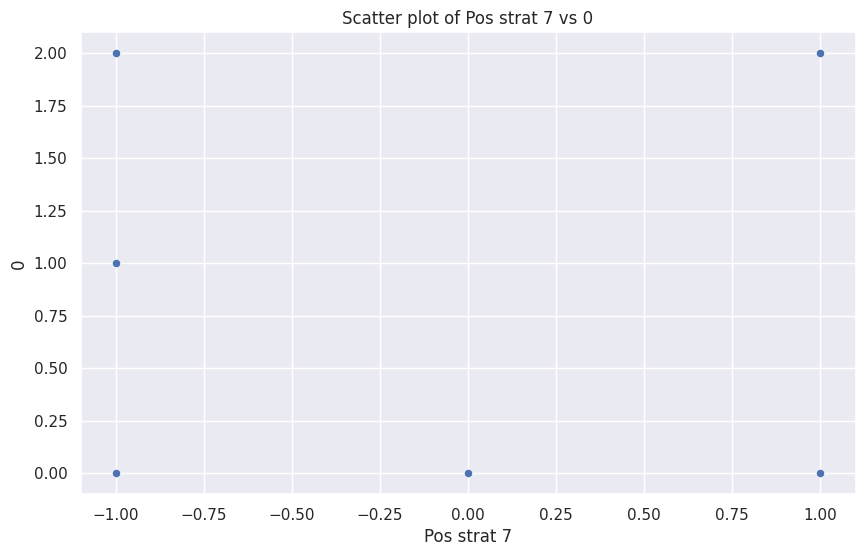

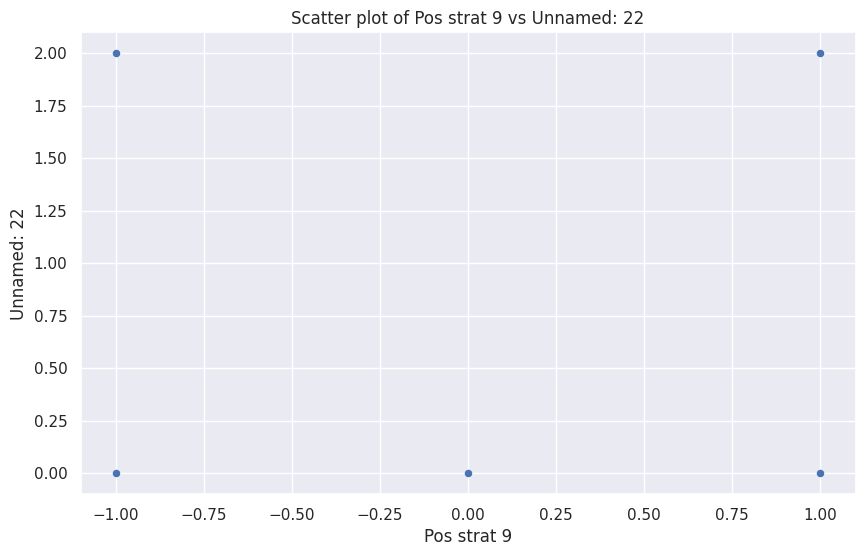

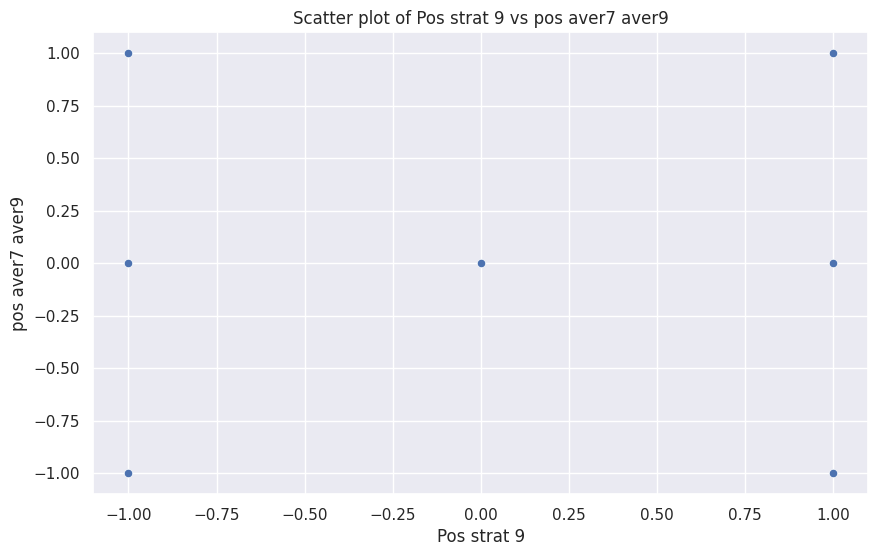

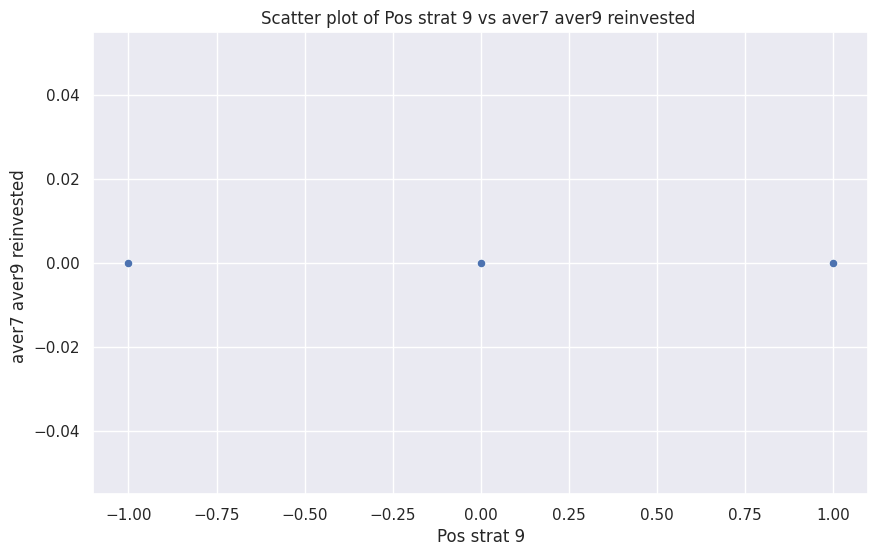

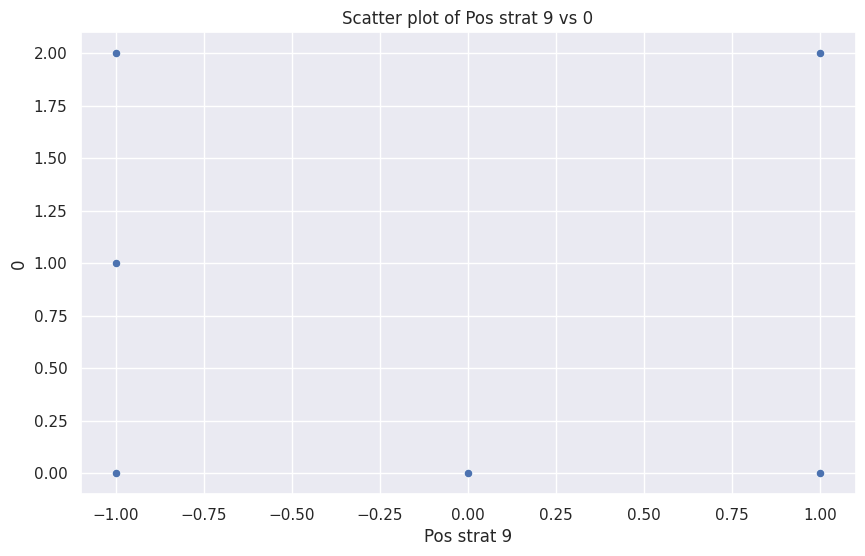

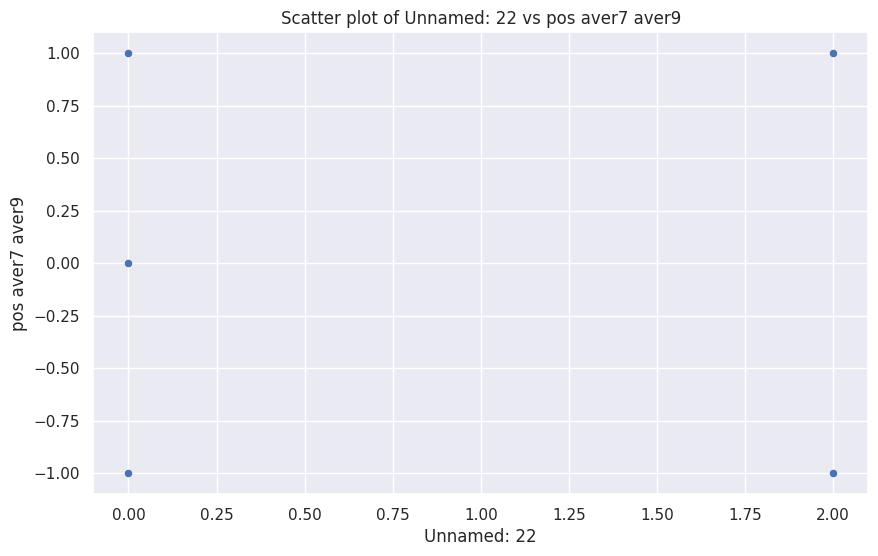

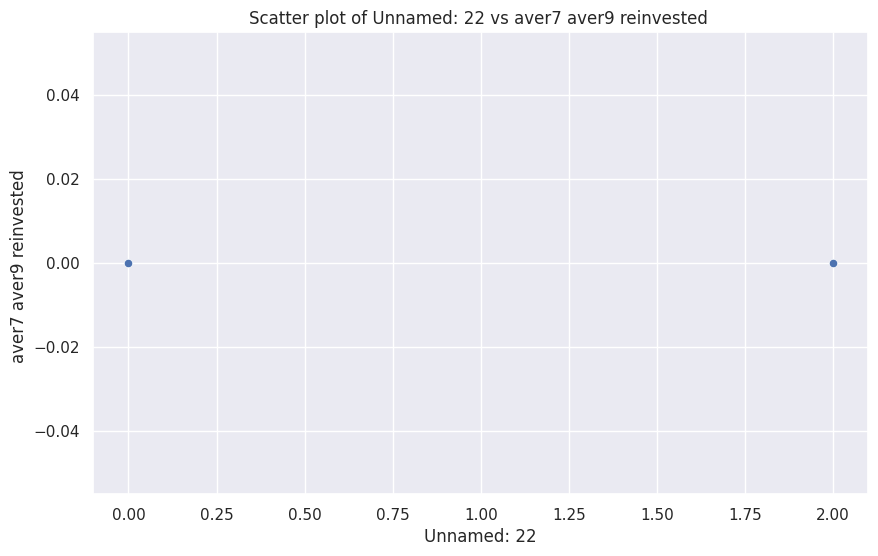

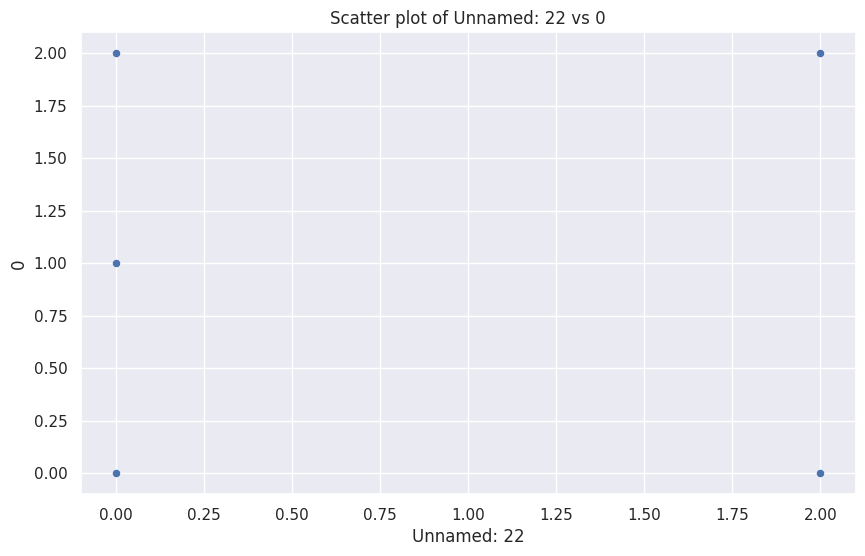

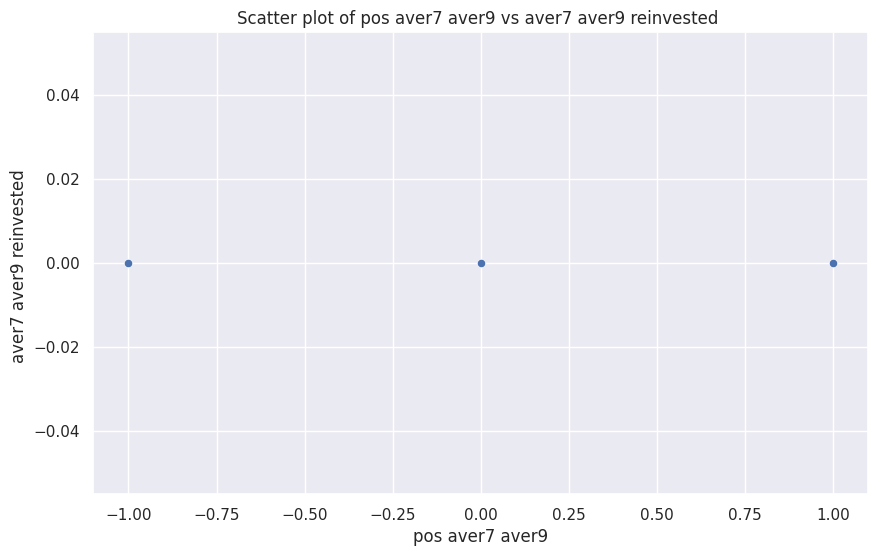

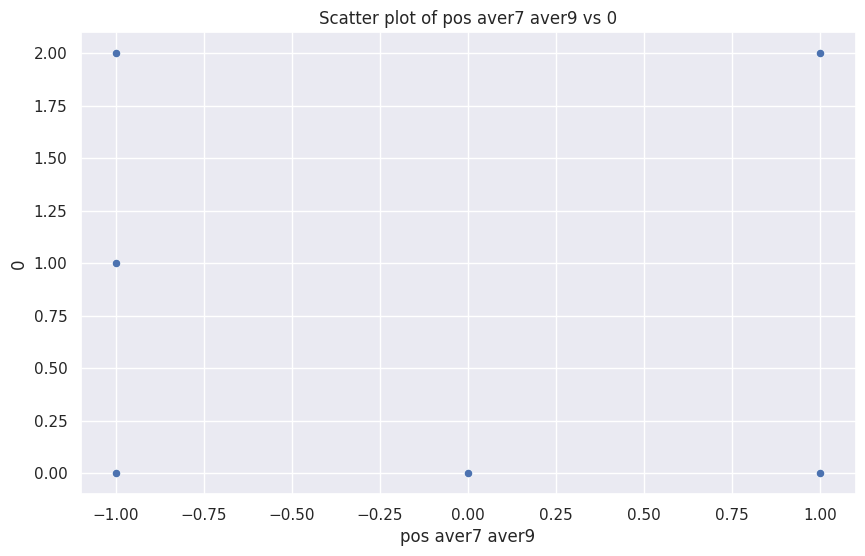

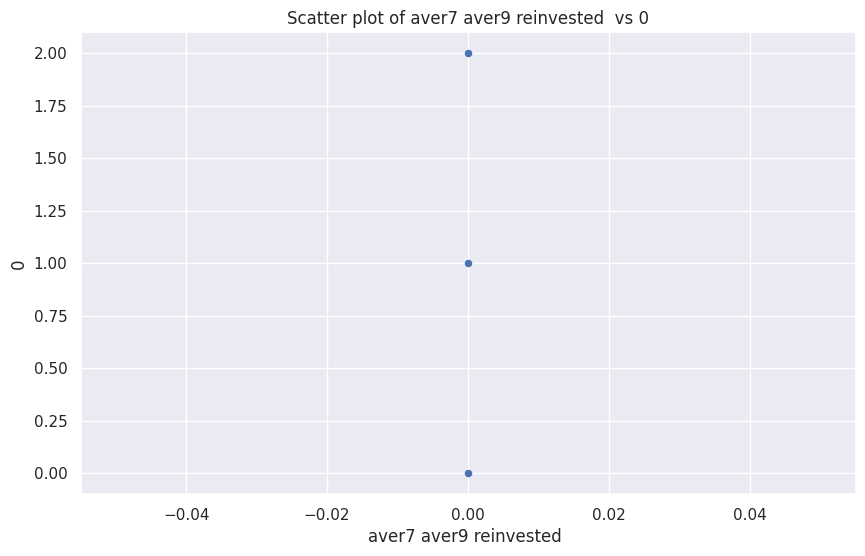

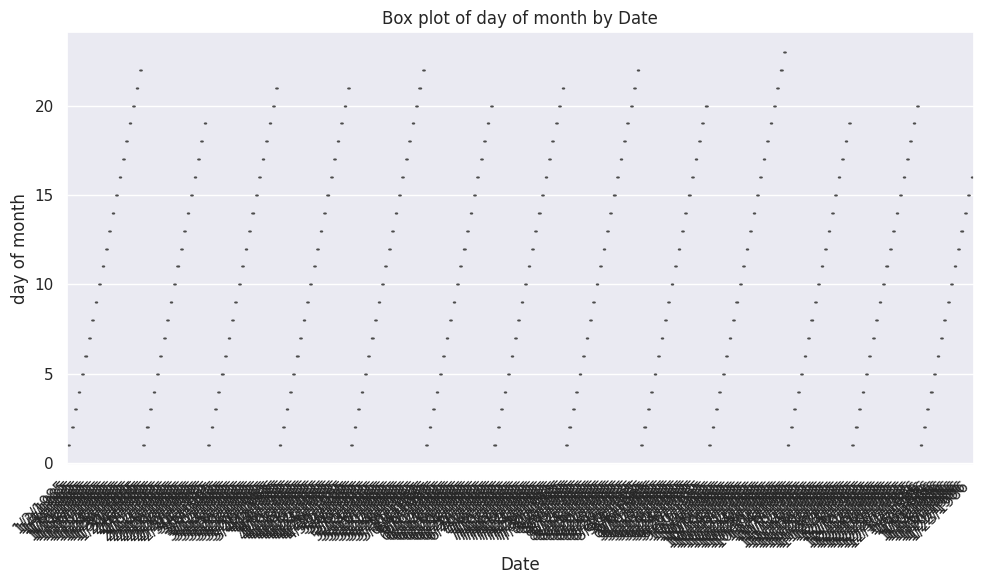

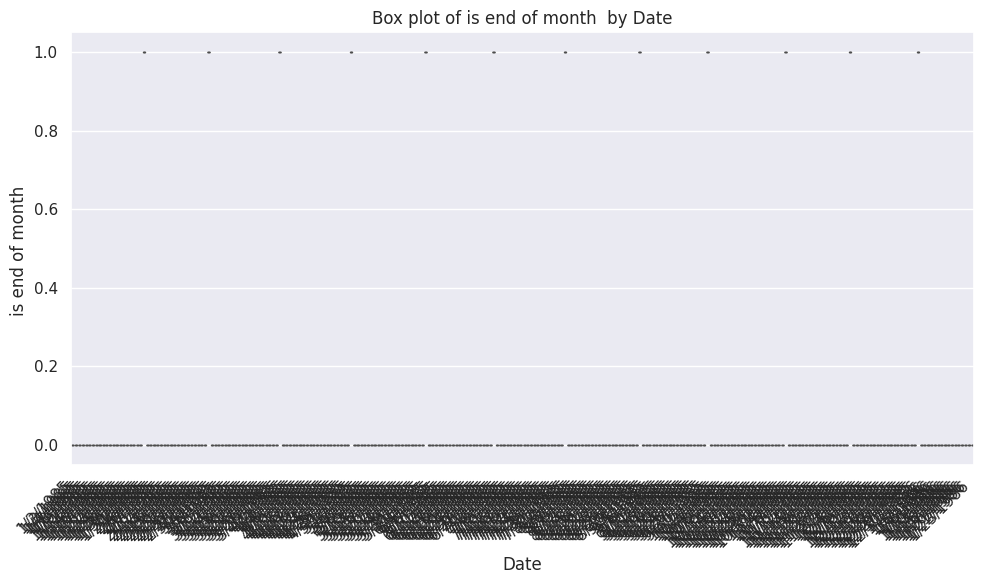

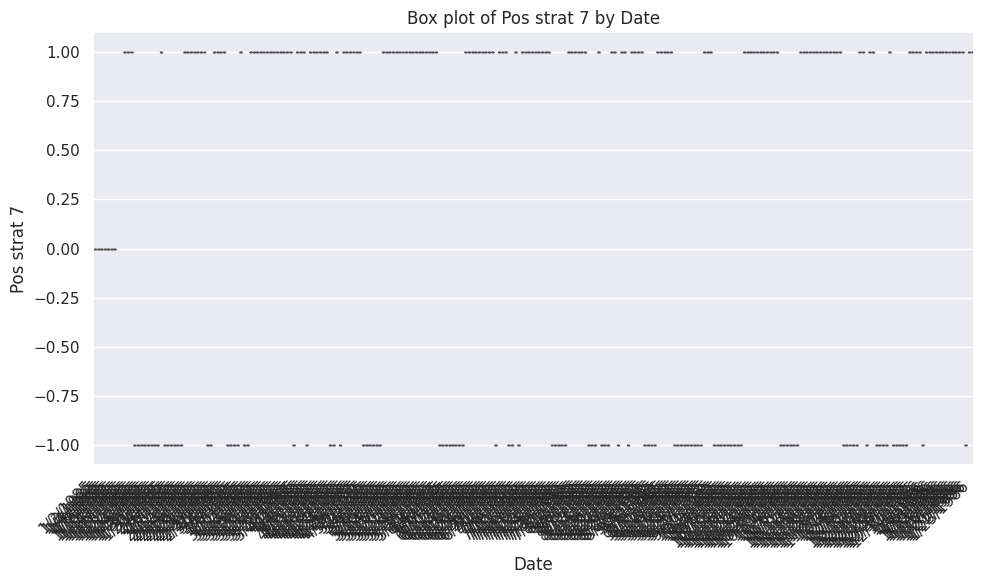

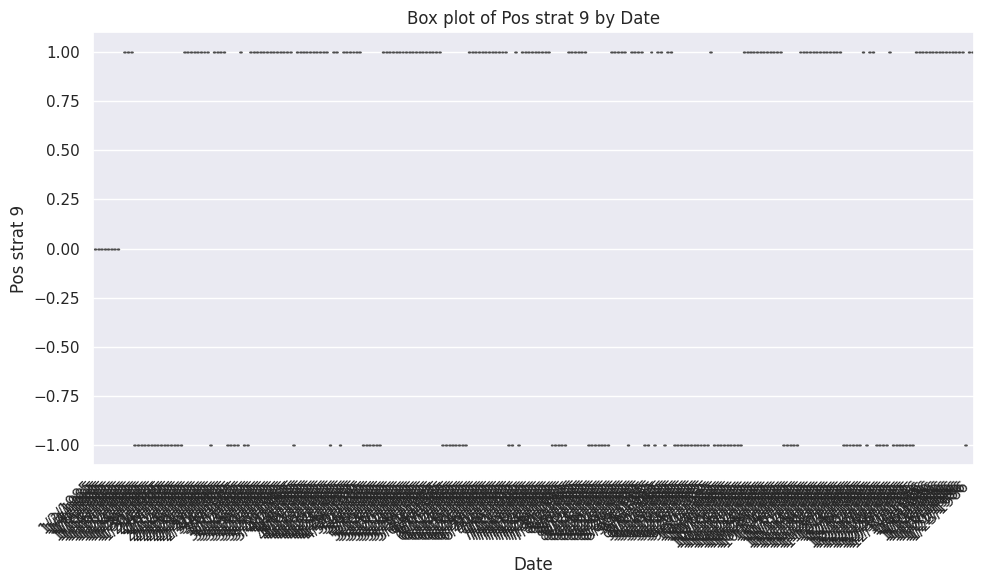

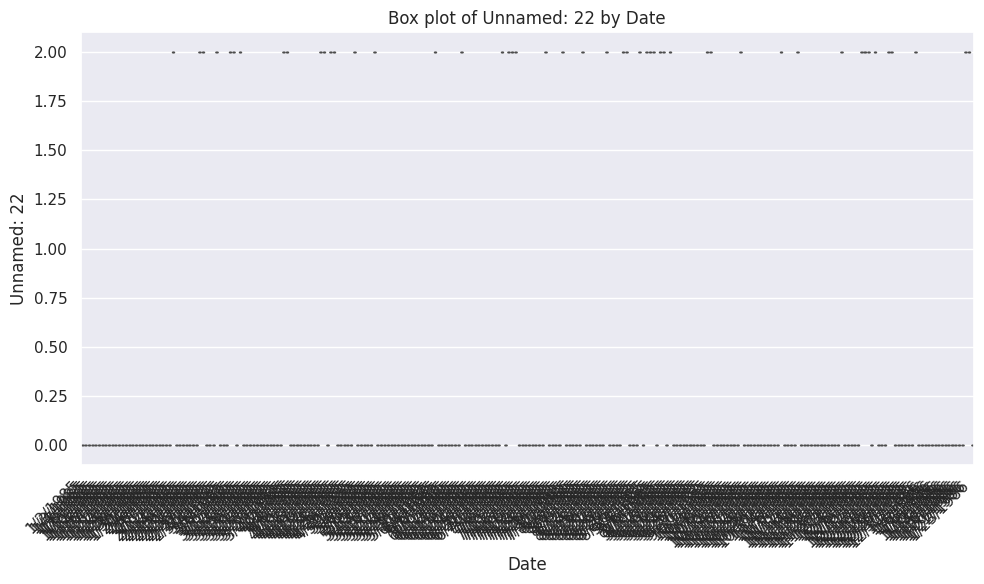

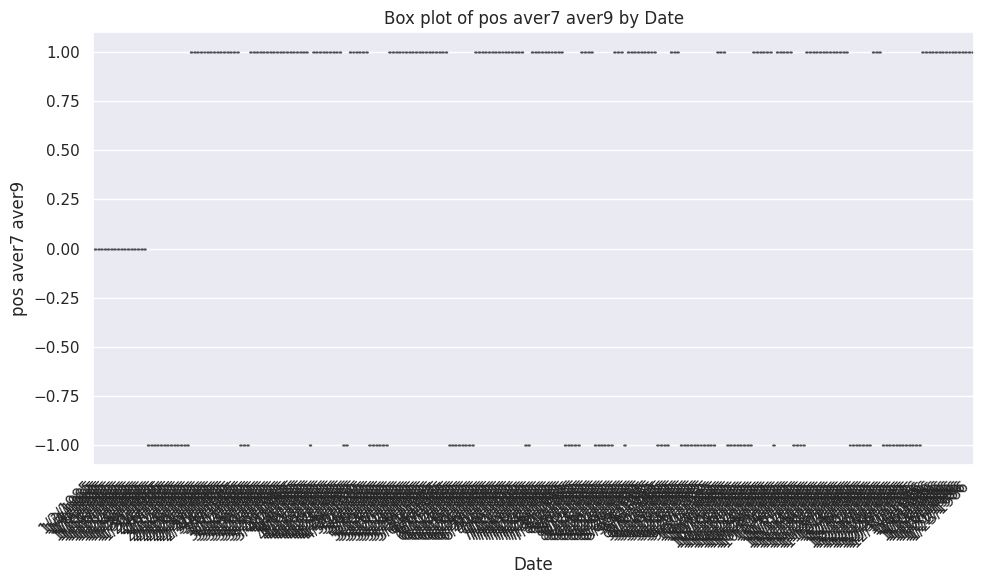

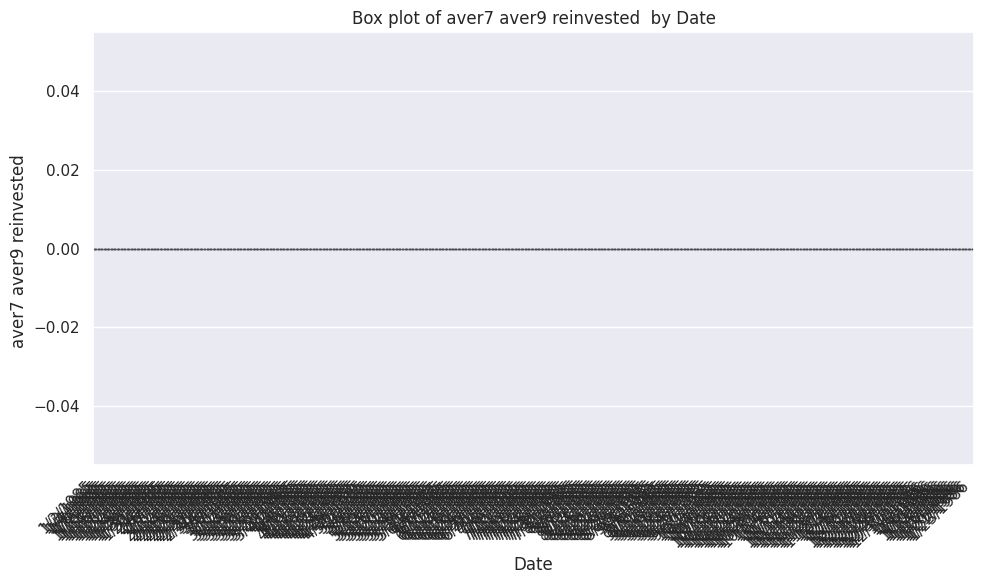

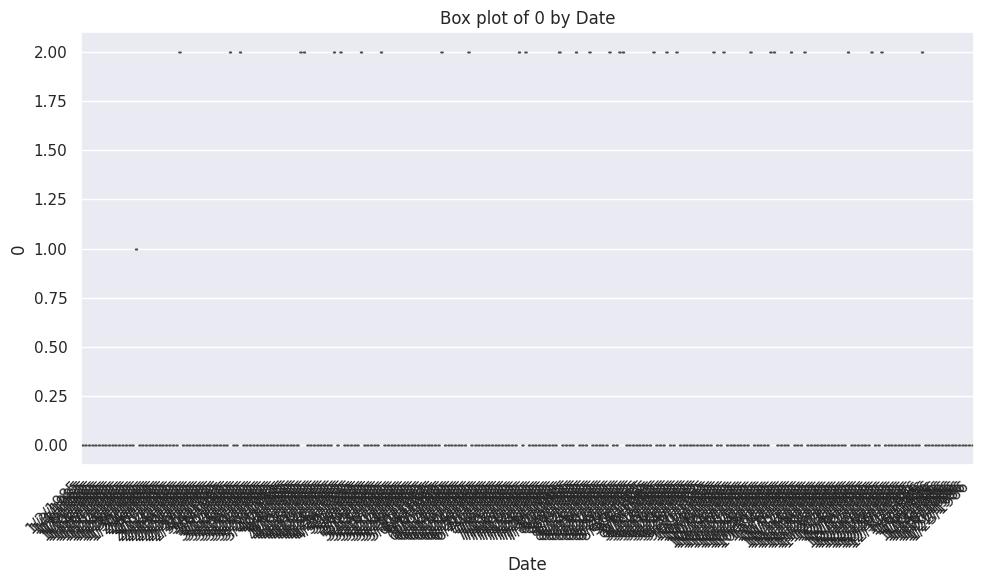

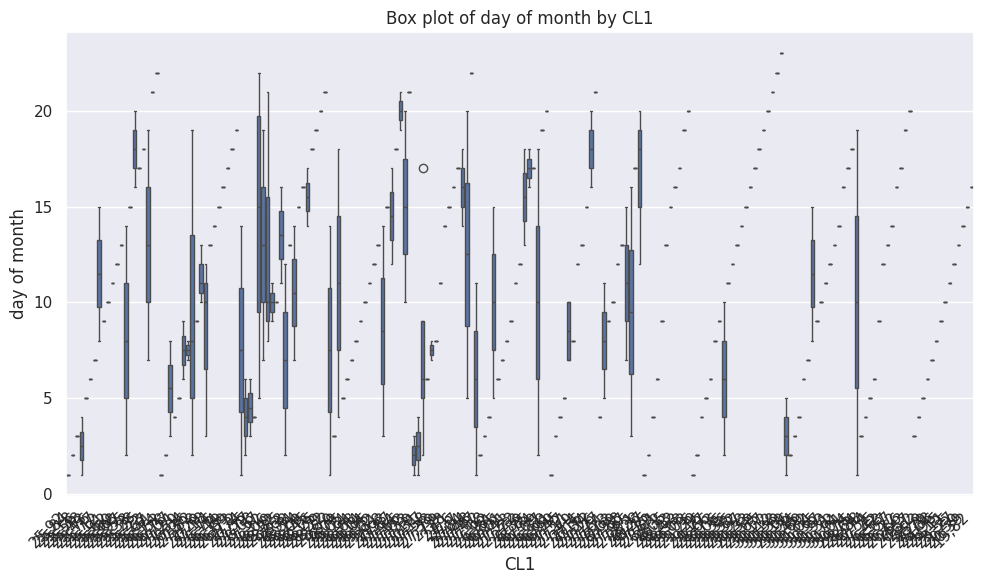

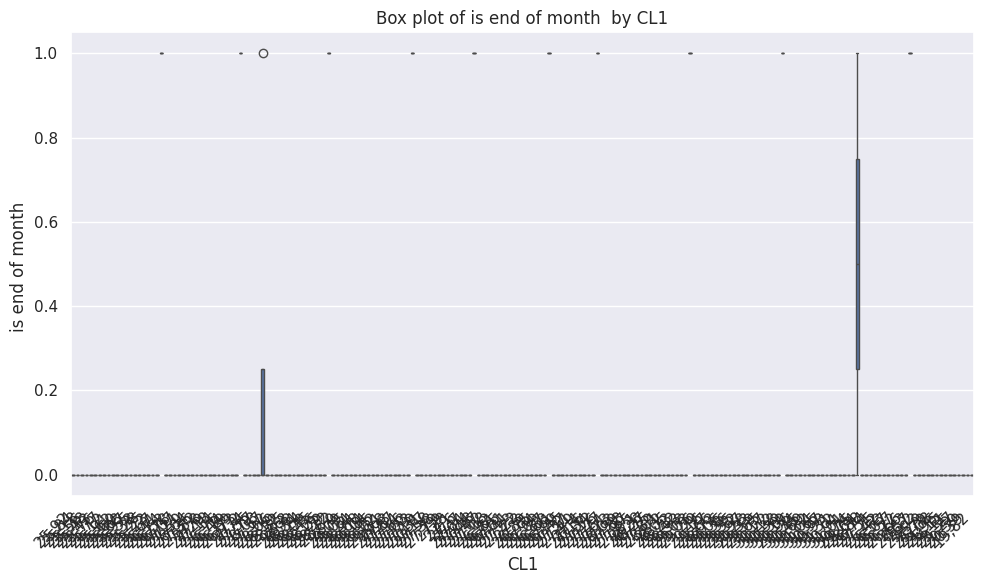

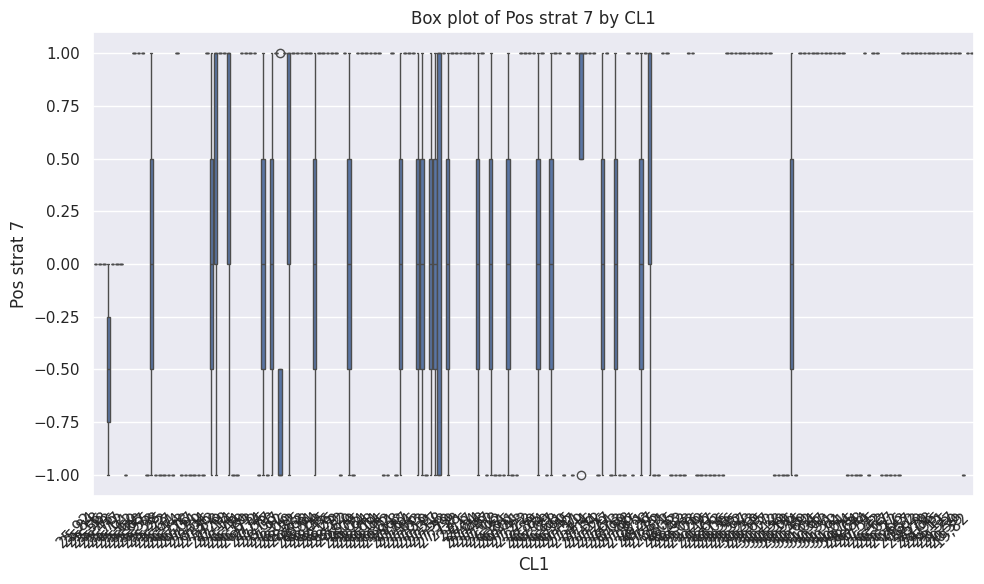

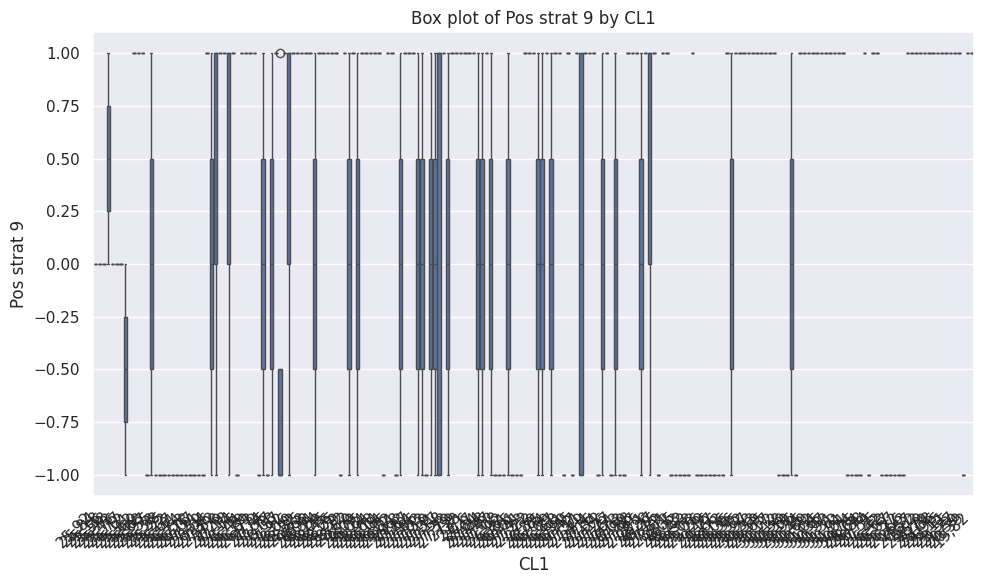

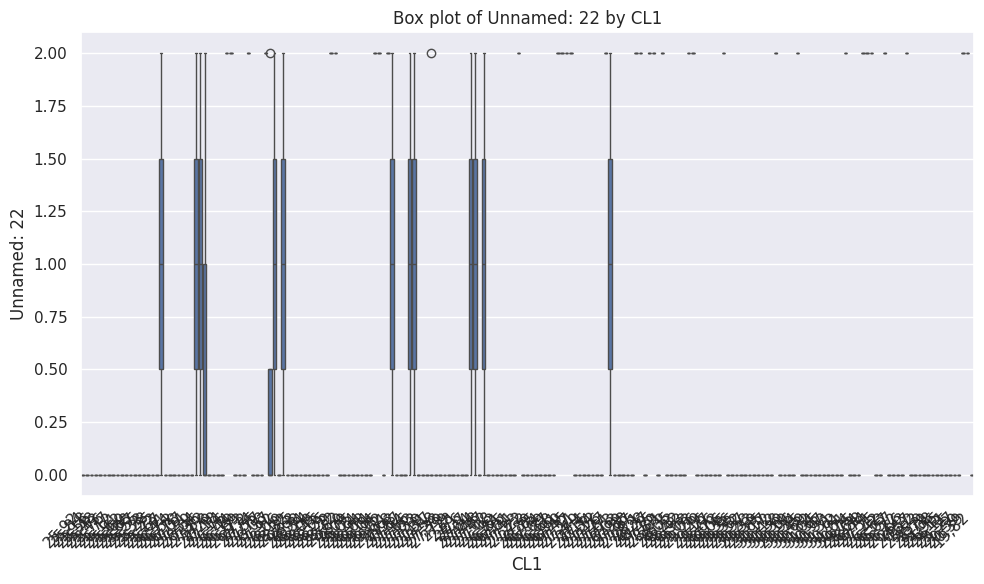

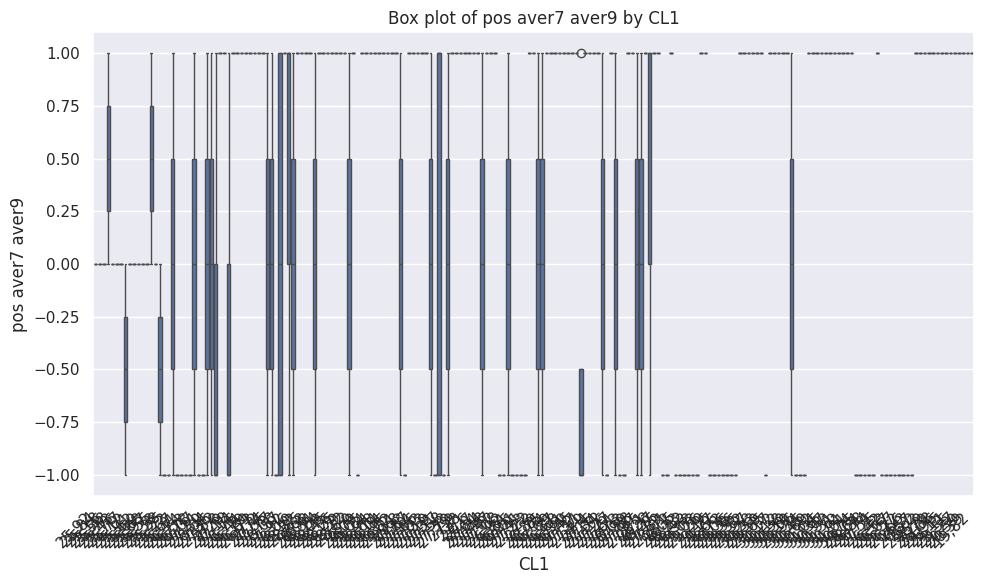

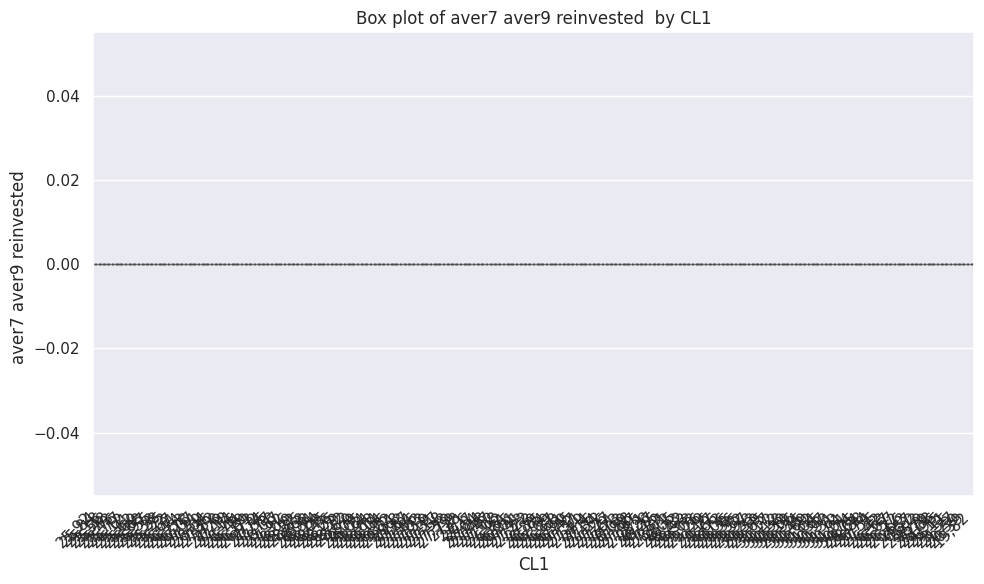

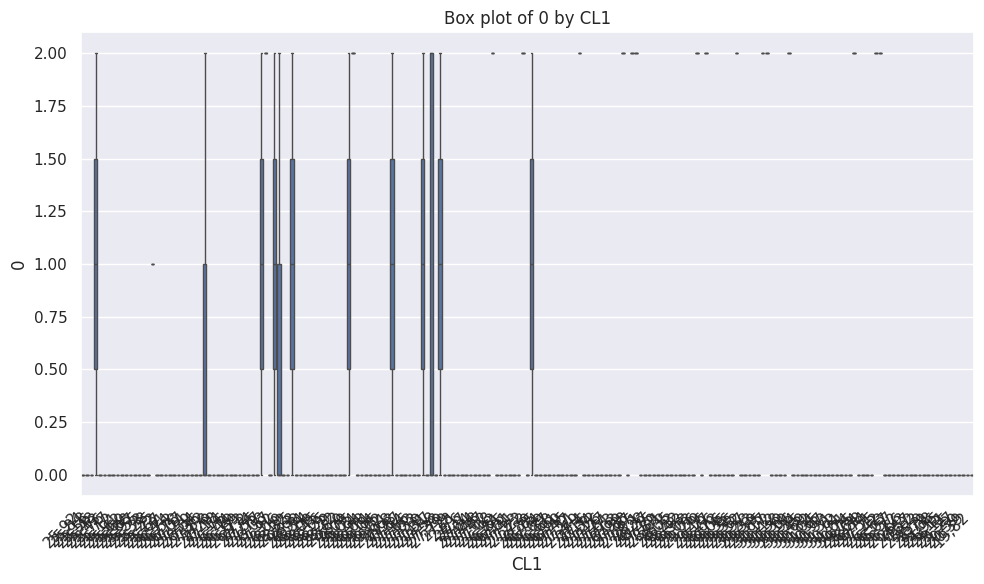

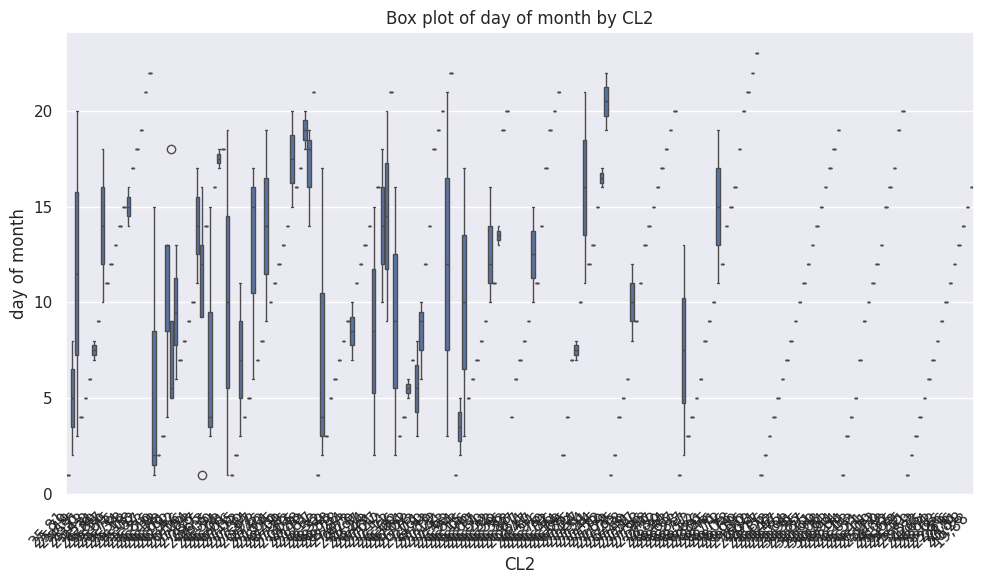

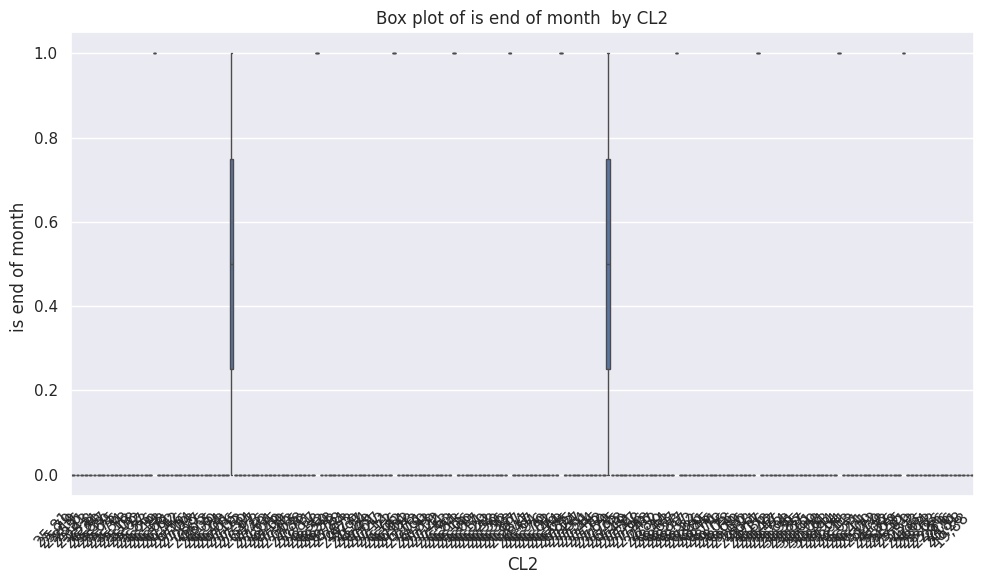

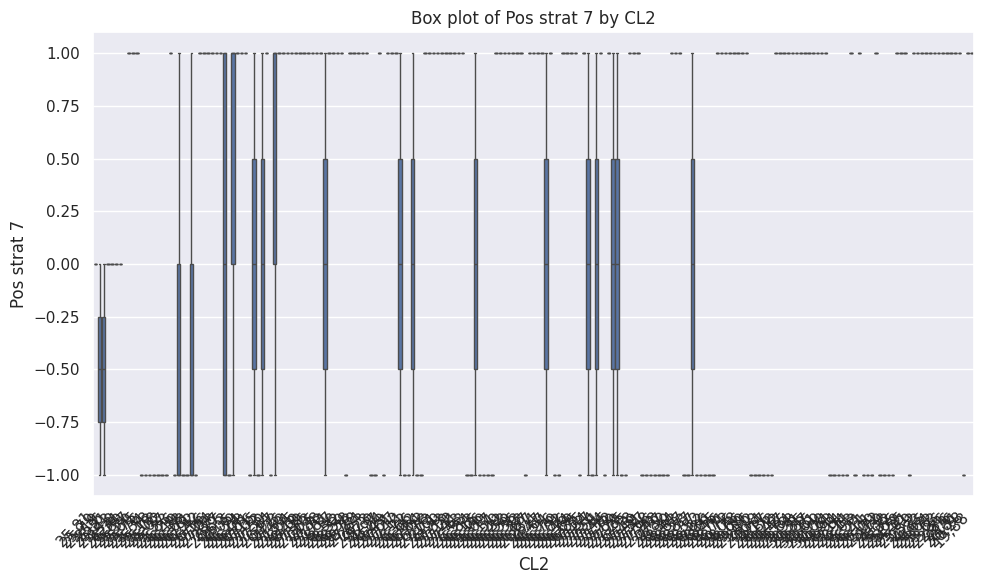

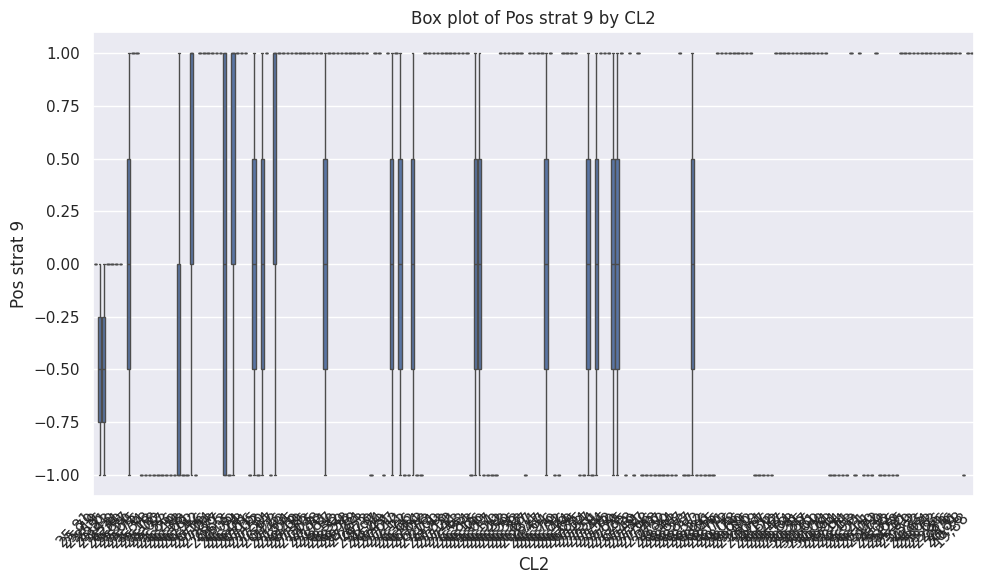

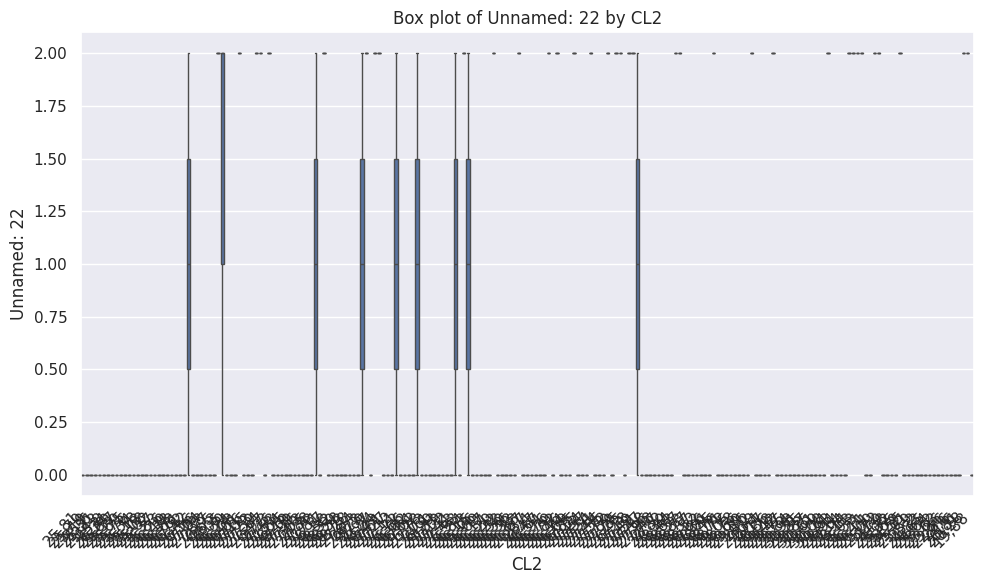

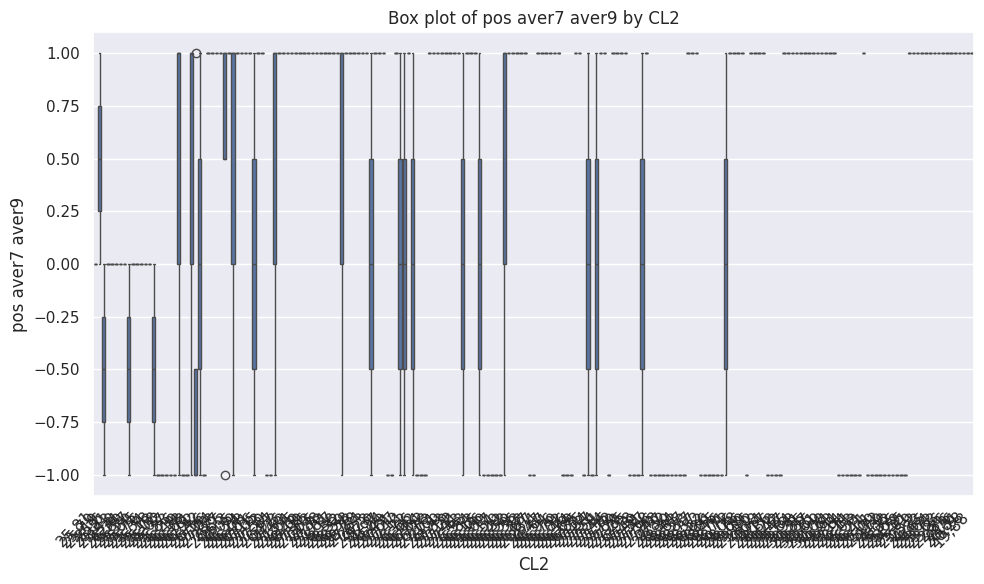

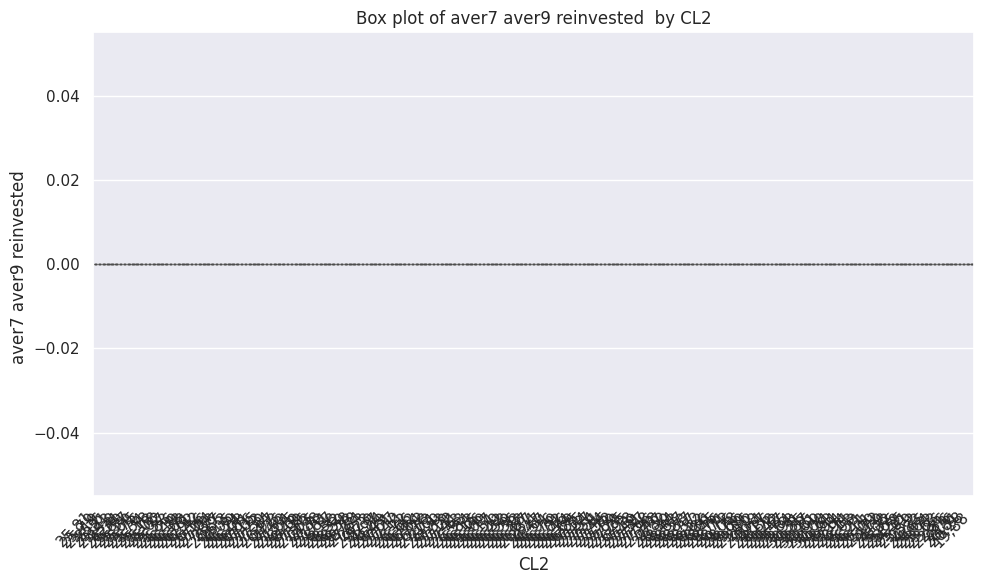

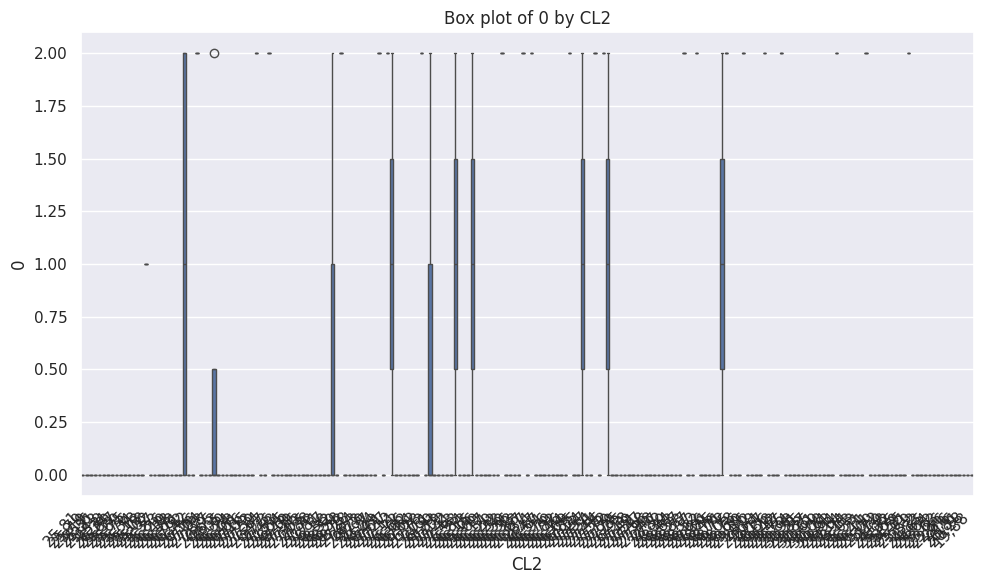

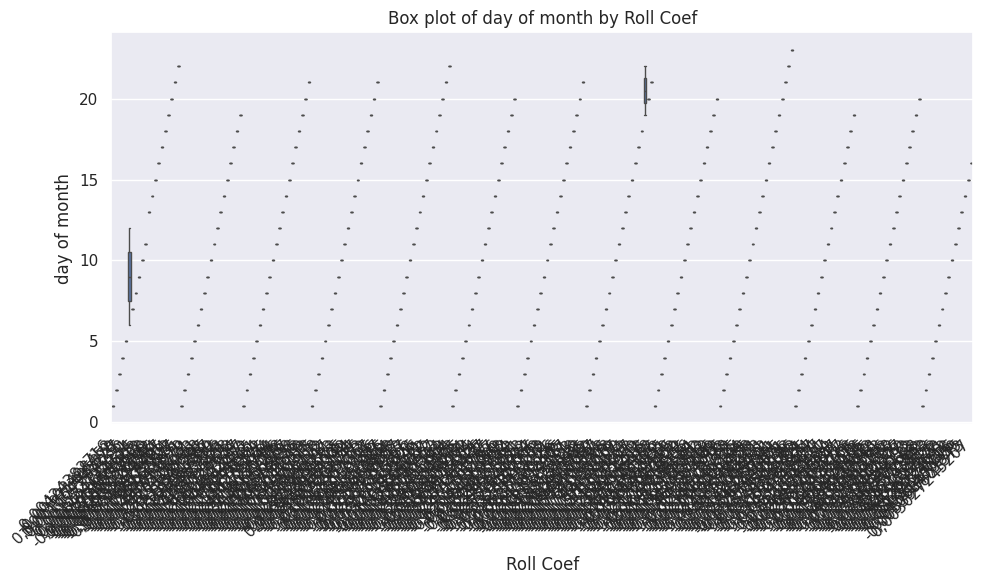

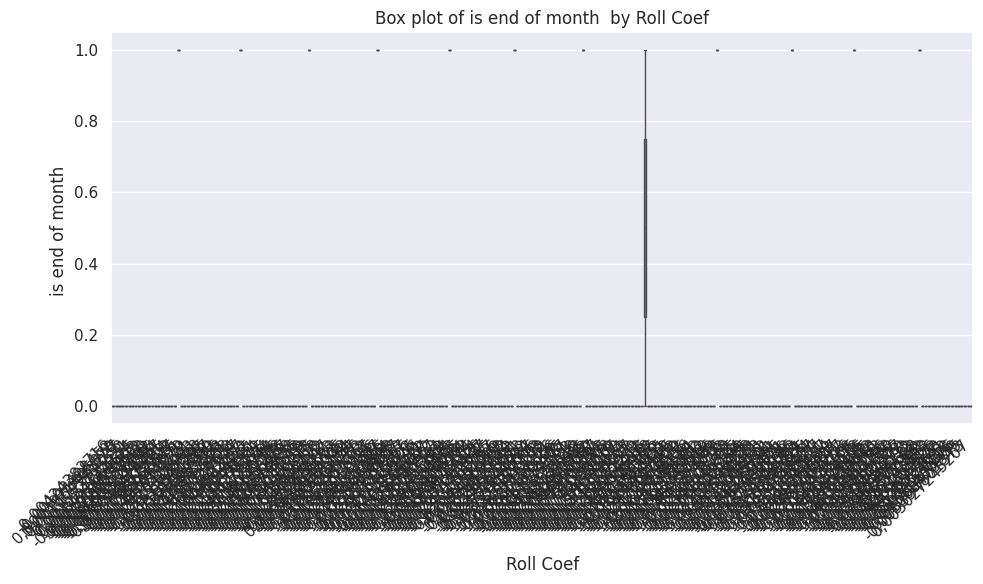

In [ ]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

In [ ]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank you